In [1]:
include("BarrierSynthesis.jl")
# include("PlotBarriers.jl")

get_random_multi (generic function with 1 method)

In [2]:
@polyvar u[1:1]
@polyvar(x[1:4]) # x[1] is x, x[2] is y, x[3] is θ, x[4] is error
v = 0.9
    dynamics = [
        (ctrl -> [v*(2.0/π)*(x[3] + π/2.0)-0.2x[4],v*(-2.0/π)*(x[3]+π)-0.2x[4], ctrl[1], 0.]),
        (ctrl -> [v*(2.0/π)*(x[3] + π/2.0)-0.2x[4],v*(2.0/π)*x[3]+0.2x[4], ctrl[1], 0]),
        (ctrl -> [v*(-2.0/π)*(x[3] - π/2.0)+0.2x[4],v*(2.0/π)*x[3]+0.2x[4], ctrl[1], 0]),
        (ctrl -> [v*(-2.0/π)*(x[3] - π/2.0)+0.2x[4],v*(-2.0/π)*(x[3]-π)-0.2x[4], ctrl[1], 0]),
    ]
g = 0.1^2 - x[1]^2 - x[2]^2 # Obstacle: is a (x,y) ball of radius 0.1 around origin
bounds = [[-10., 10.], [-10., 10.], [-π,π], [-1.,1.]]

4-element Vector{Vector{Float64}}:
 [-10.0, 10.0]
 [-10.0, 10.0]
 [-3.141592653589793, 3.141592653589793]
 [-1.0, 1.0]

In [3]:
K = 1.0
δ = 1.0
τ = 0.1
ϵ = 0.1
α = 0.6
max_degree=4
# Synthesis control set should match simulation actuation limits.
# U = [[-7.0], [7.0]]
n_tests = 200
# U = collect(range(-7.0, stop=7.0, length=6))
U_min = -10.0
U_max = 10.0
N = 9

U = [[x] for x in range(U_min, U_max, length=N)]

9-element Vector{Vector{Float64}}:
 [-10.0]
 [-7.5]
 [-5.0]
 [-2.5]
 [0.0]
 [2.5]
 [5.0]
 [7.5]
 [10.0]

In [4]:
test_pts = [ get_random(bounds, g) for _ in 1:n_tests]

200-element Vector{Vector{Float64}}:
 [5.153362959866543, -2.562888038277902, 0.07030388759257455, -0.31726377510527537]
 [5.323118968053706, -5.726625551299007, 1.6405872574930243, 0.47532978548882077]
 [7.588277881930843, -1.6277572813298864, 2.332874838498852, -0.8394568454145668]
 [-8.323878009606467, -1.419793105213321, -0.47739738303029267, 0.7139292021988752]
 [-0.5241724793039211, 0.7551688755724797, -2.465634742576762, 0.8307406565049251]
 [-6.182039104355688, -6.668739851955721, -0.28420430002074104, -0.8785561963213118]
 [1.6497231099731824, -7.382258822548113, -0.35322451860769455, -0.6928863433349692]
 [-5.112962285567111, -7.226903338645747, 1.1471598976069037, 0.05511158487867518]
 [6.027918791576884, 4.5564277780806925, -2.2666330245853117, 0.2876250105223541]
 [-0.464472819545378, 1.138123620825798, -2.2039110417343637, -0.5087675218818279]
 [-1.1557957862642247, 1.6857539313590237, 2.5731498742562957, 0.7253940325348471]
 [1.0953234934070508, -0.22321652459932295, 2.5

In [5]:
function findRepulsiveBarrier_HybridDB(x, ctrl::Vector{Float64}, g, dynamics, test_pts; max_degree=4, ϵ=1.0, τ=0.1, γ=10.0, K=1.0, δ=1.0, α=1.0, state_bounds=bounds)
    function prepare_domain_hybrid(var, lb, ub)
        dom = @set(var >= lb) ∩ @set(var <= ub) ∩ @set((var - lb) * (ub - var) >= 0)
        return dom
    end
    
    @assert τ > 0.0 "τ must be positive."
    @assert δ > 0.0 "δ must be positive."
    @assert K >= 0.0 "K must be nonnegative."
    @assert α > 0.0 "α must be positive."

    λ = (1.0 / τ) * log(1.0 + K / δ)

    solver = optimizer_with_attributes(MosekTools.Optimizer)
    model = SOSModel(solver)

    monos = monomials(x, 0:max_degree)
    N = length(monos)
    @variable(model, -γ <= c[1:N] <= γ)
    B = polynomial(c[1:end], monos)

    dom_list = prepare_domain(x, state_bounds)
    D = reduce((s1, s2) -> s1 ∩ s2, dom_list)
    println("Domain: $D")

    # 1) Unsafe-set positivity on obstacle states (g >= 0 denotes the obstacle interior)
    @constraint(model, B >= ϵ, domain = D ∩ @set(g >= 0))

    # 2) Decrease condition under each hybrid mode and fixed control
    for (i, dyn_i) in enumerate(dynamics)
        dyn_with_ctrl = dyn_i(ctrl)
        dBdt = dot(differentiate(B, x), dyn_with_ctrl)
        dom_i = prepare_domain_hybrid(x[3], (i - 3) * π / 2, (i - 2) * π / 2)
        @constraint(model, dBdt <= λ * B, domain = D ∩ dom_i)
    end

    # 3) Bounded-jump condition: B(y - yo, z) - B(y, z) <= K for yo in obstacle set
    @polyvar q1 q2
    Qα = @set(α^2 - q1^2 - q2^2 >= 0)
    B_shift = subs(B, x[1] => x[1] - q1, x[2] => x[2] - q2)
    @constraint(model, K >= B_shift - B, domain = D ∩ Qα)

    # set_objective_sense(model, MOI.FEASIBILITY_SENSE)
    set_objective_sense(model, MOI.MIN_SENSE)
    objective_fn = sum((B(pt...) for pt in test_pts); init=0.0)
    # With unsafe encoded as B > 0, minimize B on test points to expand the certified safe set B <= 0.
    @objective(model, Min, objective_fn)

    JuMP.optimize!(model)
    stat = JuMP.primal_status(model)
    solution_summary(model)
    println("Status obtained: $(stat)")

    if stat != FEASIBLE_POINT
        return missing
    end

    return value(B), K
end

findRepulsiveBarrier_HybridDB (generic function with 1 method)

In [6]:
function synthesize_barriers_over_controls_dubins(U, x, g, dynamics, test_pts; max_degree=4, ϵ=0.1, τ=0.1, K=1.0, δ=1.0, α=0.6, state_bounds=bounds)
    pts_work = copy(test_pts)
    results = NamedTuple[]
    cumulative_time = 0.0
    for (i, u_i) in enumerate(U)
        ctrl = Float64.(u_i)
        println("Synthesizing barrier $(i)/$(length(U)) for u = ", ctrl)
        t_start = time()
        res_i = findRepulsiveBarrier_HybridDB(x, ctrl, g, dynamics, pts_work; max_degree=max_degree, ϵ=ϵ, τ=τ, K=K, δ=δ, α=α, state_bounds=state_bounds)
        elapsed = time() - t_start
        cumulative_time += elapsed
        if res_i === missing
            println("  -> synthesis failed, skipping this control (elapsed=", round(elapsed, digits=3), " s, cumulative=", round(cumulative_time, digits=3), " s)")
            continue
        end

        B_i, K_i = res_i
        push!(results, (idx=i, u=ctrl[1], B=B_i, K=K_i, solve_time=elapsed, cumulative_time=cumulative_time, synth_order=i))
        pts_work = filter!(pt -> B_i(pt...) > 0.0, pts_work)
        println("  -> success, remaining candidate points: ", length(pts_work), " (elapsed=", round(elapsed, digits=3), " s, cumulative=", round(cumulative_time, digits=3), " s)")
    end
    return results, pts_work
end

synth_start = time()
barrier_data, test_pts = synthesize_barriers_over_controls_dubins(
    U, x, g, dynamics, test_pts;
    max_degree=max_degree, ϵ=ϵ, τ=τ, K=K, δ=δ, α=α, state_bounds=bounds,

 )
synth_elapsed = time() - synth_start

@assert !isempty(barrier_data) "No barriers synthesized from the Dubins control grid."

all_barriers = [item.B for item in barrier_data]
barrier_controls_synth = [item.u for item in barrier_data]
all_K = [item.K for item in barrier_data]

println("Synthesized ", length(all_barriers), " barriers out of ", length(U), " controls.")
println("Total synthesis wall time: ", round(synth_elapsed, digits=3), " s")
println("Cumulative solve times for computed barriers:")
for item in sort(barrier_data, by=r -> r.synth_order)
    println("  order=", item.synth_order, ", idx=", item.idx, ", u=", item.u, ", solve=", round(item.solve_time, digits=3), " s, cumulative=", round(item.cumulative_time, digits=3), " s")
end
display(barrier_controls_synth)

Synthesizing barrier 1/9 for u = [-10.0]
Domain: { (x[1], x[2], x[3], x[4]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 3.141592653589793 + x[3] ≥ 0, 3.141592653589793 - x[3] ≥ 0, 9.869604401089358 - x[3]^2 ≥ 0, 1.0 + x[4] ≥ 0, 1.0 - x[4] ≥ 0, 1.0 - x[4]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 560             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 70              
  Matrix variables       : 92 (scalarized: 2465)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 0
Eliminator terminated.
Eliminator

9-element Vector{Float64}:
 -10.0
  -7.5
  -5.0
  -2.5
   0.0
   2.5
   5.0
   7.5
  10.0

In [7]:
println("Total synthesized barriers: ", length(all_barriers))
display(all_barriers)


Total synthesized barriers: 9


9-element Vector{Polynomial{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, Graded{LexOrder}, Float64}}:
 1.2142381470693264 + 0.019350171039886045x₄ - 0.5398843899155389x₃ - 0.07210479169176662x₂ - 0.038713924315019896x₁ + 0.0032790116791206864x₄² - 0.013968109282657076x₃x₄ + 0.16558204048795244x₃² + 0.0001416760593134536x₂x₄ + 0.048083256639409266x₂x₃ - 0.03442267928195403x₂² + 0.0012473109326048724x₁x₄ + 0.02239113343016312x₁x₃ + 0.0010041959004855859x₁x₂ - 0.03836362968604158x₁² - 0.0002454355176604113x₄³ + 0.0008220007307136243x₃x₄² - 0.0034261054572554926x₃²x₄ + 0.08860209227132519x₃³ - 6.385505219347788e-5x₂x₄² - 0.0008161773877479213x₂x₃x₄ - 0.017530342206043006x₂x₃² - 0.00010668165534436968x₂²x₄ + 0.011604476939841978x₂²x₃ + 0.0003875569567553295x₂³ - 8.16073984270885e-5x₁x₄² - 0.0008582802256475149x₁x₃x₄ - 0.006617958333256523x₁x₃² - 4.871761832247679e-6x₁x₂x₄ - 0.00039407883543514204x₁x₂x₃ + 0.0002406405740834829x₁x₂² - 0.00013288910397502582x₁²x₄ + 0.01306

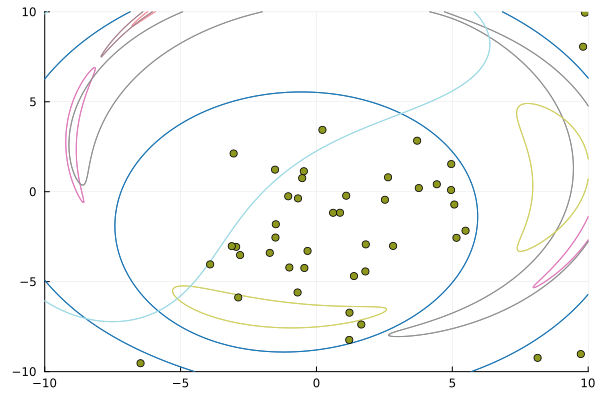

In [8]:
using Plots

function make_contour_plot(B::Polynomial, limits::Tuple{Float64, Float64}, clr; x3_val=0.0, x4_val=0.0)
    x = range(limits[1], limits[2], length=500)
    y = range(limits[1], limits[2], length=500)
    my_fun(xa::Float64, ya::Float64) = B([xa, ya, x3_val, x4_val])
    z = @. my_fun(x', y)
    contour!(x, y, z, levels=[0.0, 0.0], color=clr, colorbar=false)
end

limits = (-10.0, 10.0)
plot(xlims=limits, ylims=limits)

plot_colors = palette(:tab20, max(length(all_barriers), 4))
for (i, B) in enumerate(all_barriers)
    make_contour_plot(B, limits, plot_colors[i])
end

plot!([x1 for (x1, _) in test_pts], [x2 for (_, x2) in test_pts], seriestype=:scatter, labels=false)

In [9]:
using LaTeXStrings
function circleShape(x,y, r)
    θ = LinRange(0, 2*π, 500)
    x .+ r*cos.(θ), y .+ r*sin.(θ)
end
function plot_ics_region(limits::Tuple{Float64,Float64}, all_barriers::Vector{<:Polynomial}; δ = 0.5, x3_val=π/2,x4_val=0.)
    plot(xlims=limits, ylims=limits)
    rectangle(w, h, x, y) = Shape(x .+ [0,w,w,0], y .+ [0,0,h,h])
    for x in limits[1]:δ:limits[2]
        for y in limits[1]:δ:limits[2]
           if (any([ B(x, y, x3_val, x4_val) <= 0. for B in all_barriers]))
              plot!(rectangle(δ, δ, x-δ, y-δ), label=false, fill=:green, opacity=0.5,linecolor=:green)
           end
        end
    end
    plot!(circleShape(0,0,1.), seriestype =[:shape], lw=0.5, c=:black, linecolor=:black, legend=false, aspectratio=1  )
    plot!(xlims=limits, ylims=limits)
end

plot_ics_region (generic function with 1 method)

In [10]:
println("all_barriers count = ", length(all_barriers))
println("barrier_controls_synth count = ", length(barrier_controls_synth))

all_barriers count = 9
barrier_controls_synth count = 9


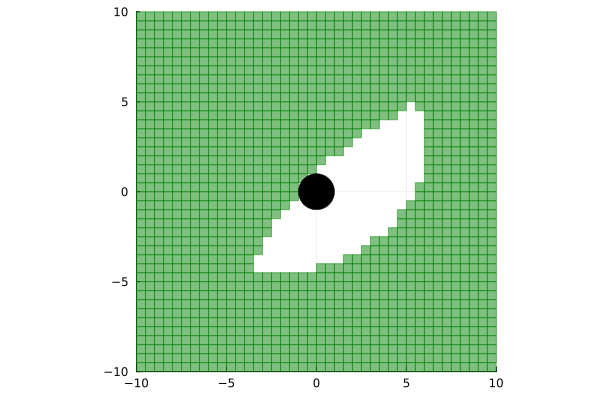

In [11]:
plot_ics_region((-10.0, 10.0), all_barriers; x3_val=2.,x4_val=0)

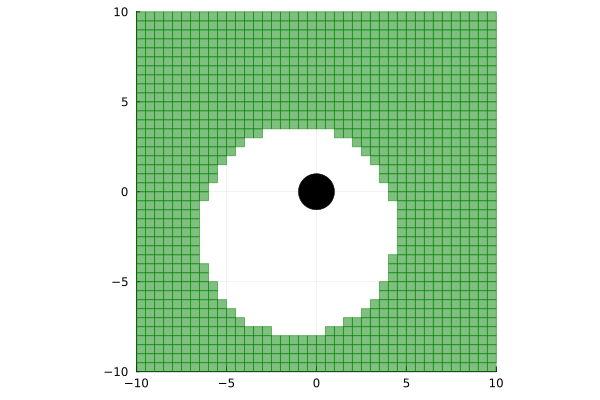

In [12]:
plot_ics_region((-10.0, 10.0), all_barriers; x3_val=-2.,x4_val=0)

timing: dt_sim=0.02, τ_recenter=0.1, τ_steps_run=5


[ Info: Saved animation to /Users/rameez/workspace/moving_obs_barrier/figures/repulsive_hybrid_dubins_moving_obstacle.gif


Simulation finished
minimum recentered barrier value = -8.967852148853957
minimum true obstacle distance = 6.446019301899625
mean tracking error = 4.229091514560367
max tracking error = 7.5224113747307095
number of barrier overrides = 352
Animation saved to figures/repulsive_hybrid_dubins_moving_obstacle.gif
override ratio: 0.224


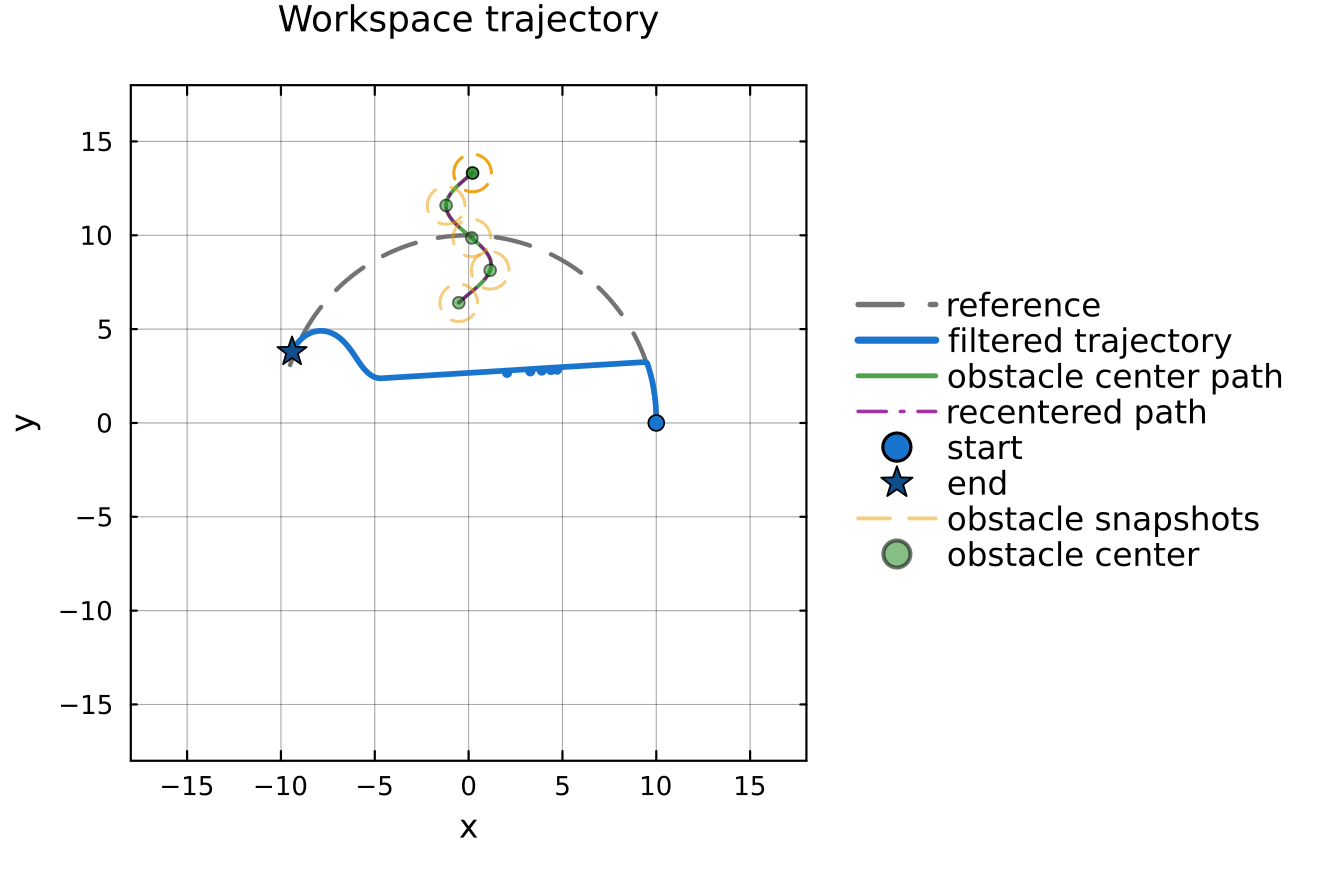

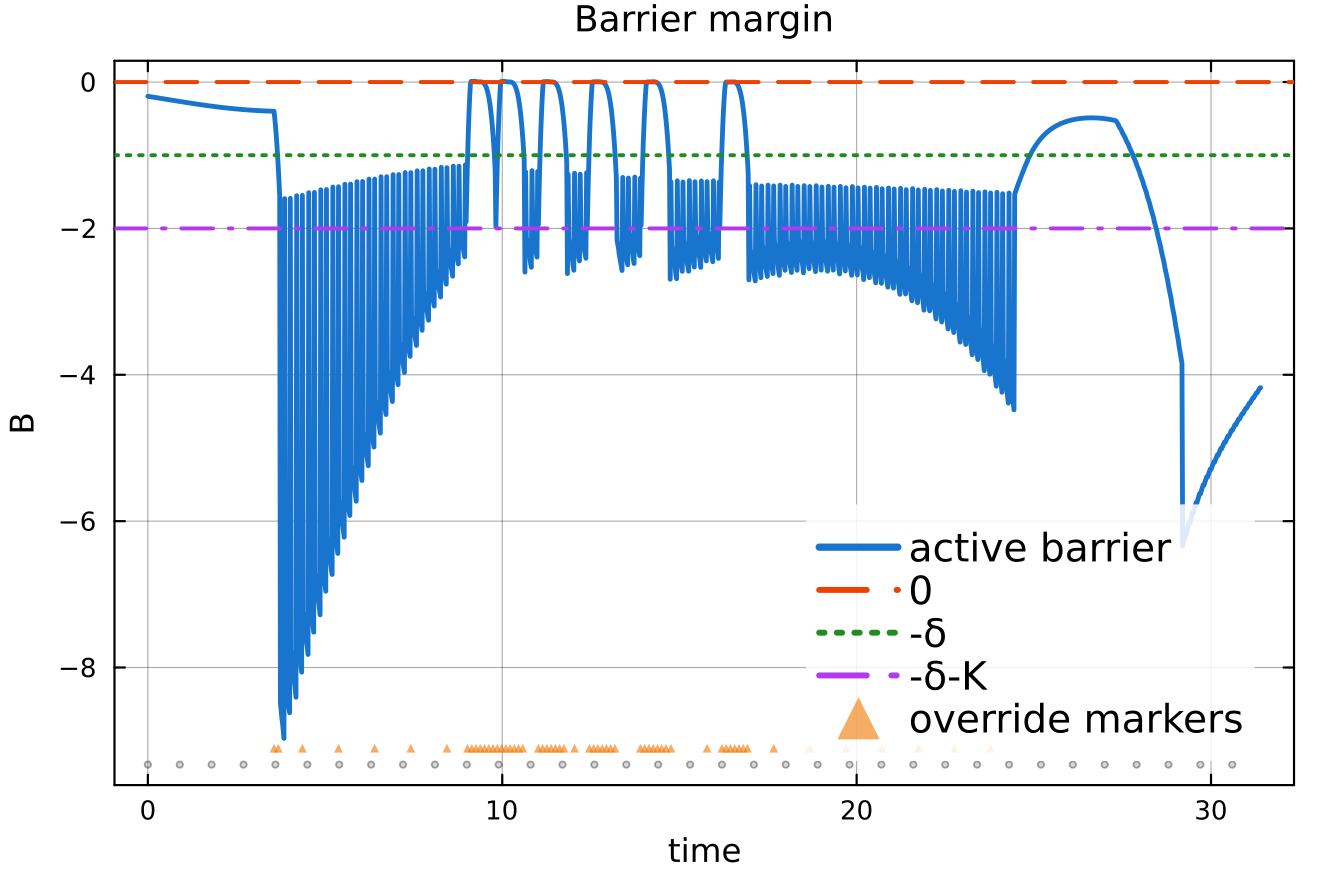

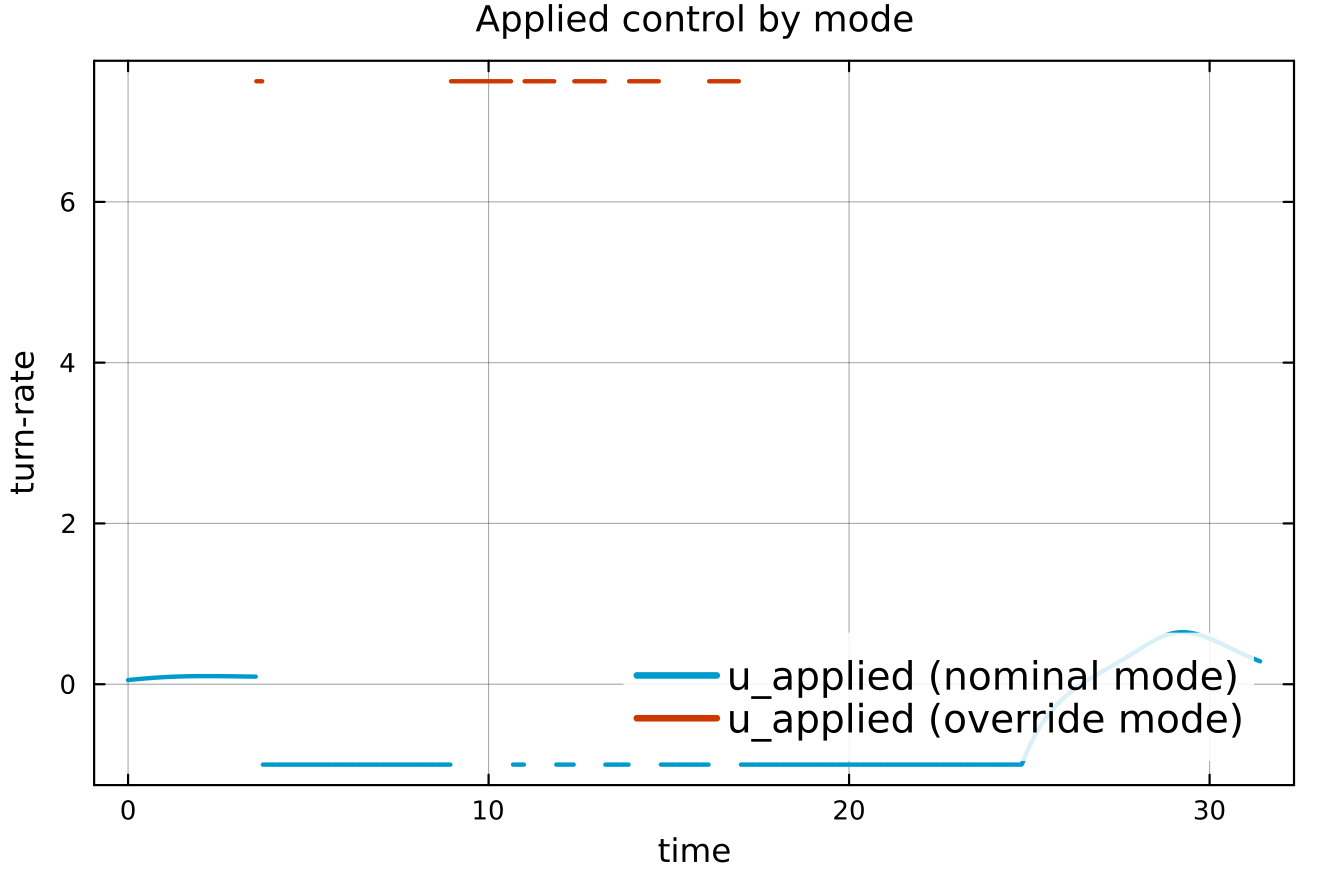

In [13]:
include("Repulsive_hybrid_dubins_recenter_fix_plotting_improved.jl")
barrier_controls = barrier_controls_synth
# barrier_controls = clamp.(barrier_controls_raw, -1.5, 1.5)

τ_recenter = τ
dt_sim = min(0.02, τ_recenter / 2)
# dt_sim = 0.1
τ_steps_run = max(1, Int(round(τ_recenter / dt_sim)))
println("timing: dt_sim=$(dt_sim), τ_recenter=$(τ_recenter), τ_steps_run=$(τ_steps_run)")
ref_radius = 10.0
ref_omega = v / ref_radius
T_run = 0.9 * π * ref_radius / v
plot_half_span = 18.0
x0_run = [ref_radius, 0.0, π / 2]

cross_angles = [0.5π]
cross_times = [0.52 * T_run]

res = run_repulsive_hybrid_dubins_demo(
    all_barriers;
    v,
    τ_steps=τ_steps_run,
    dt=dt_sim,
    T=T_run,
    k_override=K,
    δ,
    barrier_controls=barrier_controls,
    umin=minimum(barrier_controls),
    umax=maximum(barrier_controls),
    x0=x0_run,
    ref_radius=ref_radius,
    ref_omega=ref_omega,
    ref_phase=0.0,
    obs_cross_angle=cross_angles,
    obs_cross_speed=0.22,
    obs_t_cross=cross_times,
    obs_half_travel=1.6,
    obs_away_offset=0.0,
    plot_half_span=plot_half_span,
)

override_ratio = count(res.barrier_override_hist) / length(res.barrier_override_hist)
println("override ratio: ", round(override_ratio, digits=3))
display(res.p_traj)
display(res.p_B)
display(res.p_u)